# Main script

## Part (i): loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model

%load_ext autoreload
%autoreload 2

data_path       = os.getenv('DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
split_data_path = "../data/train-validate-test/" # split data set
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized_train = np.load(split_data_path + XY_train_filename)['Eb_train']
Ns_standardized_train = np.load(split_data_path + XY_train_filename)['Ns_train']
Eb_standardized_valid = np.load(split_data_path + XY_valid_filename)['Eb_validation']
Ns_standardized_valid = np.load(split_data_path + XY_valid_filename)['Ns_validation']
Eb_standardized_test  = np.load(split_data_path + XY_test_filename)['Eb_test']
Ns_standardized_test  = np.load(split_data_path + XY_test_filename)['Ns_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of Ns_standardized_train:', Ns_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)


Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized_train: (256, 256, 1, 833)
Shape of Ns_standardized_train: (256, 256, 1, 833)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


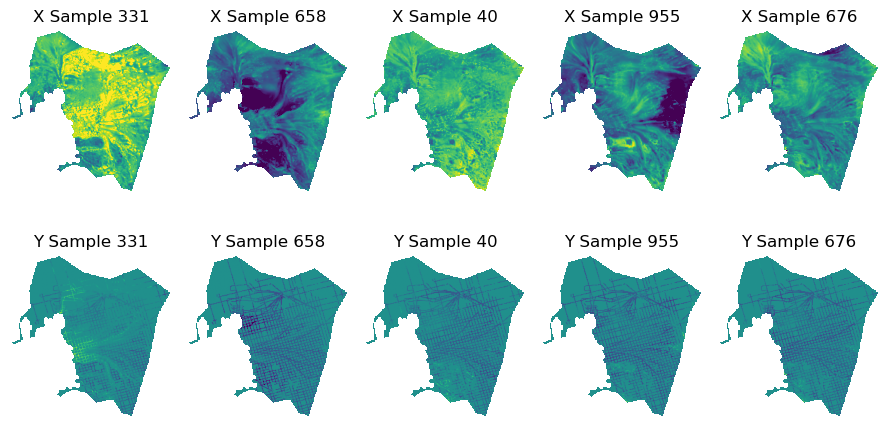

In [2]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
Ns_standardized_all = np.concatenate([Ns_standardized_train, 
                                      Ns_standardized_valid, 
                                      Ns_standardized_test], 
                                      axis=3)
md.load_sim_data(Eb_standardized_all, Ns_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

## Part (ii): inspecting data dimension with PCA

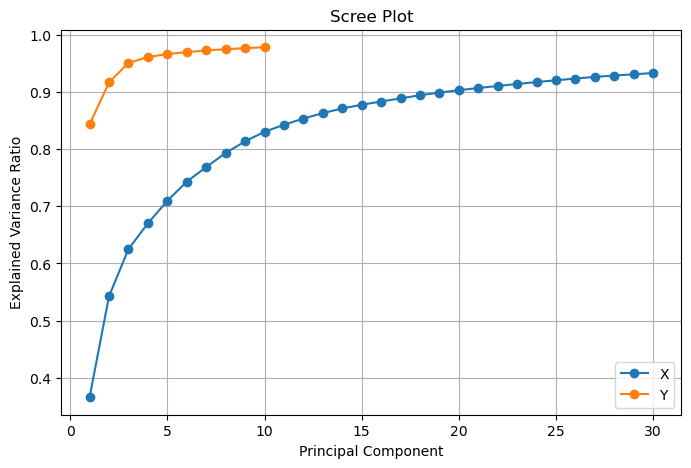

In [147]:
md.pca_scree(n_component_x=30, n_component_y=10)

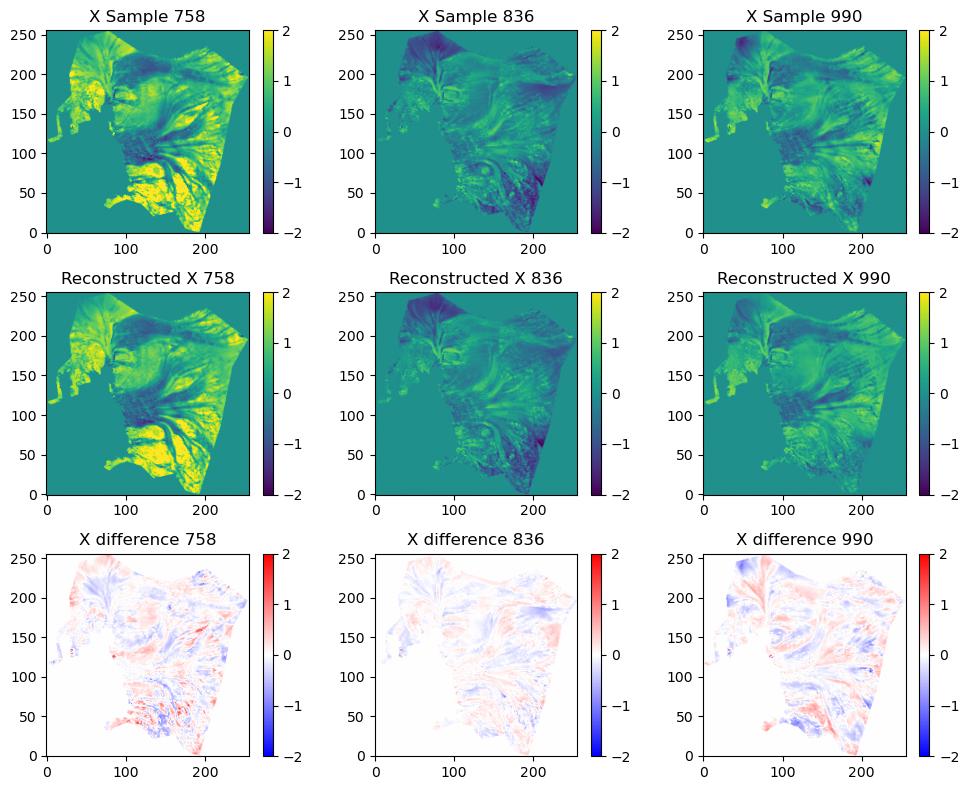

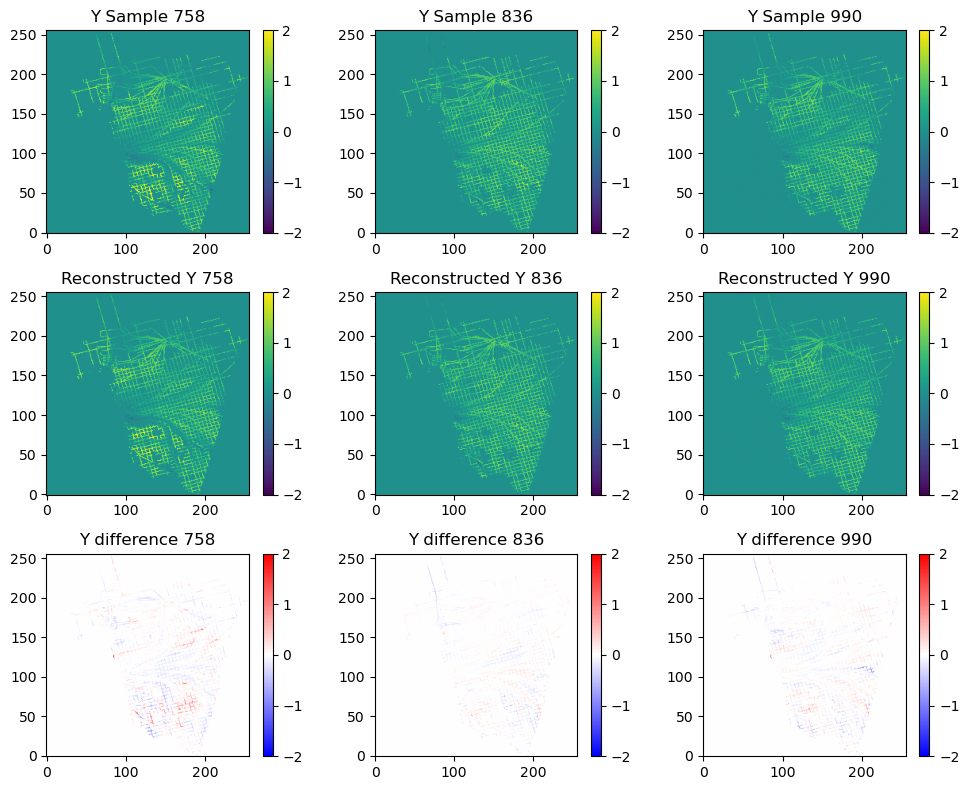

In [165]:
md.pca_recon_inspection(n_component_x=30, n_component_y=10)

## Part (iii): Dimension reduction and derive the informative prior

PCA model saved to self.pca_x and self.pca_y.
Shape of XY_train: (833, 33)
Shape of XY_validation: (104, 33)
Shape of XY_test: (105, 33)
GMM training completed in 0.01 seconds.
k*ln(n): 3994.6699834471046  - 2*L: 210364.3234192187 BIC: 214358.9934026658
n_components: 1 BIC: 214358.9934026658
GMM training completed in 0.03 seconds.
k*ln(n): 7996.065000536377  - 2*L: 194359.06680056907 BIC: 202355.13180110545
n_components: 2 BIC: 202355.13180110545
GMM training completed in 0.10 seconds.
k*ln(n): 11997.460017625648  - 2*L: 189354.7499678551 BIC: 201352.20998548076
n_components: 3 BIC: 201352.20998548076
GMM training completed in 0.07 seconds.
k*ln(n): 15998.85503471492  - 2*L: 185233.12325753088 BIC: 201231.9782922458
n_components: 4 BIC: 201231.9782922458
GMM training completed in 0.05 seconds.
k*ln(n): 20000.250051804192  - 2*L: 186556.44383464393 BIC: 206556.6938864481
n_components: 5 BIC: 206556.6938864481
GMM training completed in 0.17 seconds.
k*ln(n): 24001.645068893464  - 2*L: 17

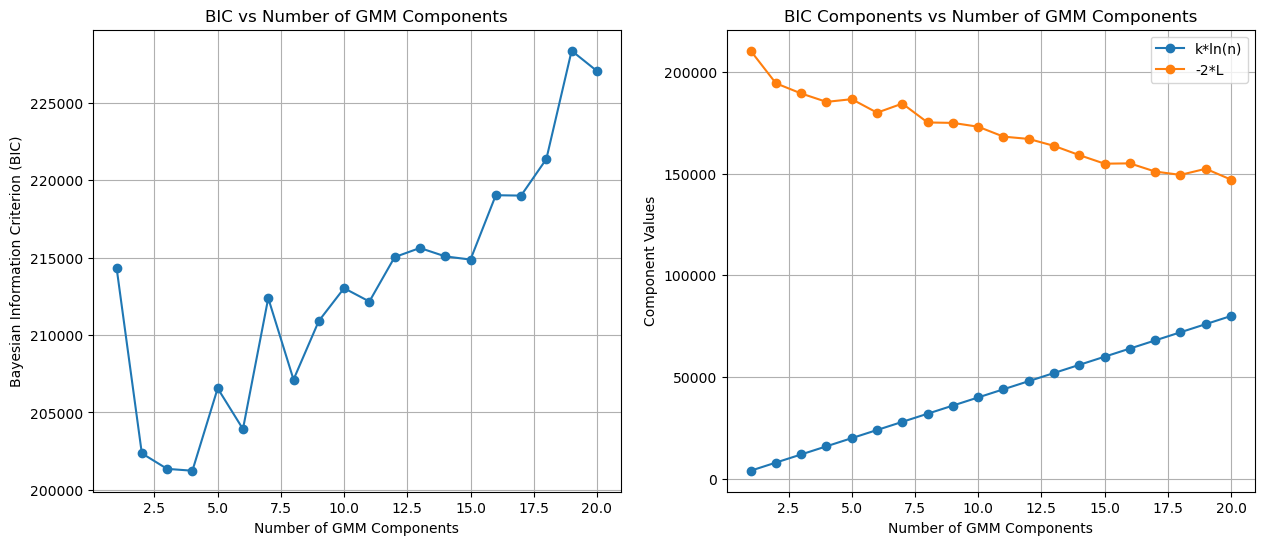

GMM training completed in 0.08 seconds.


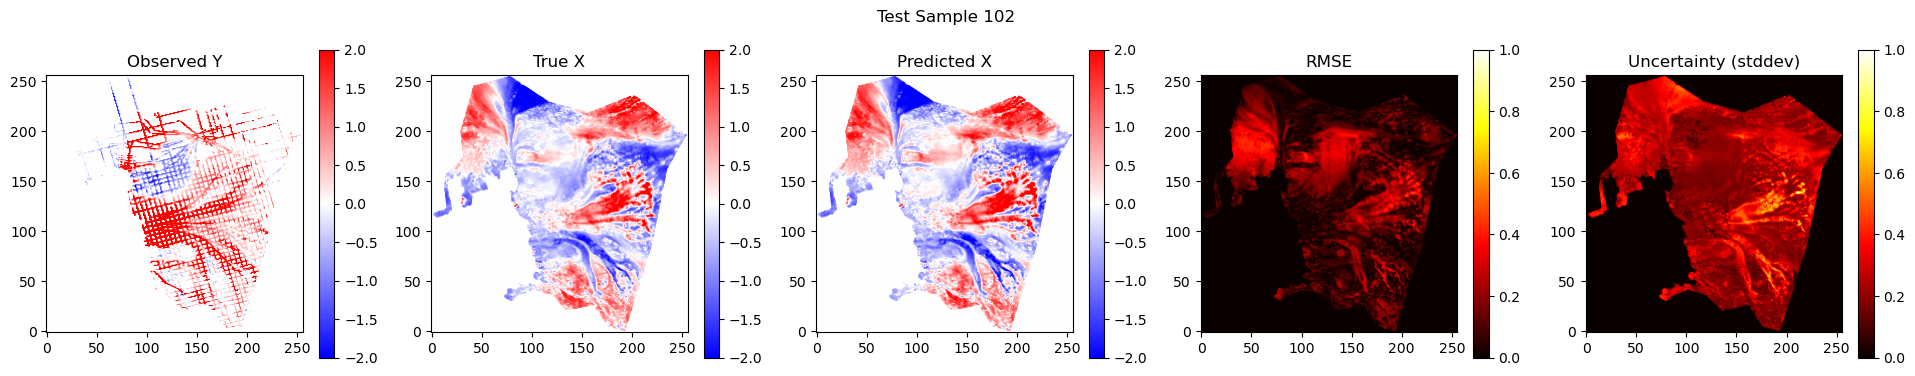

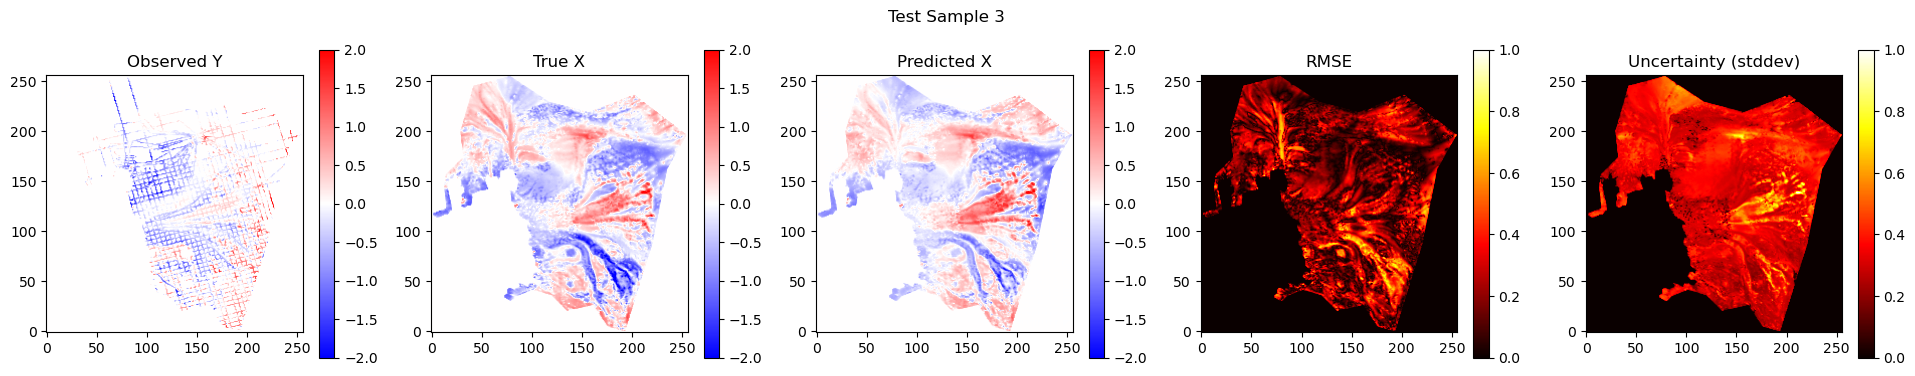

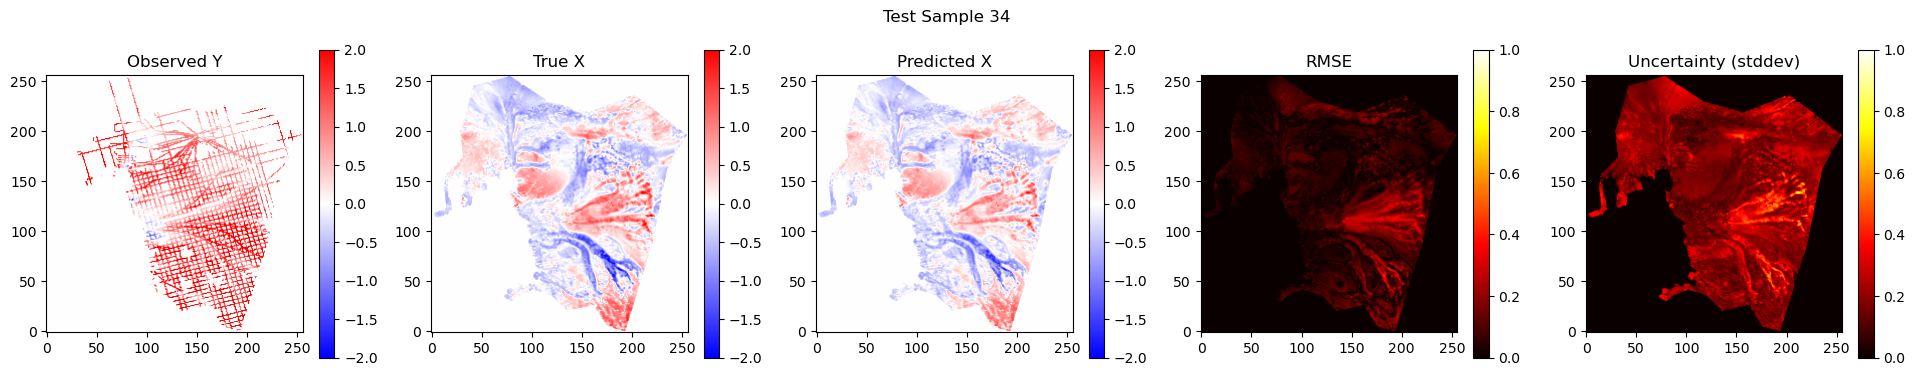

In [3]:
from src.validation import bayesian_information_criterion

# reduce dim with PCA. 
md.find_reduction_model_pca(n_component_x=25, n_component_y=8)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PCA
md.load_split_data(X_train=Eb_standardized_train, Y_train=Ns_standardized_train,
                   X_validation=Eb_standardized_valid, Y_validation=Ns_standardized_valid,
                   X_test=Eb_standardized_test, Y_test=Ns_standardized_test)

y_train = md.XY_train[:, md.y_indices]
x_train = md.XY_train[:, md.x_indices]

# Run Bayesian Information Criterion (BIC) sweep to find the optimal number of GMM components
gmm_components = np.linspace(1, 20, 20, dtype=int)
bic_list = []
kln_list = []
neg2L_list = []
for n_components in gmm_components:
    md.train_gmm_XY(n_components=n_components)
    bic, kln, neg2L = bayesian_information_criterion(md, x_train, y_train, n = md.n_samples_train)
    bic_list.append(bic)
    kln_list.append(kln)
    neg2L_list.append(neg2L)
    print("n_components:", n_components, "BIC:", bic)

plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(gmm_components, bic_list, marker='o')
plt.xlabel('Number of GMM Components')
plt.ylabel('Bayesian Information Criterion (BIC)')
plt.title('BIC vs Number of GMM Components')
plt.grid()
# plot the component
plt.subplot(1,2,2)
plt.plot(gmm_components, kln_list, marker='o', label='k*ln(n)')
plt.plot(gmm_components, neg2L_list, marker='o', label='-2*L')
plt.xlabel('Number of GMM Components')
plt.ylabel('Component Values')
plt.title('BIC Components vs Number of GMM Components')
plt.legend()
plt.grid()
plt.show()

# based on the BIC sweep plot
n_optimal = 4 
md.train_gmm_XY(n_components=n_optimal)
md.plot_gmm_samples_pca(n_samples=3)

shape of Y_obs: (256, 256)


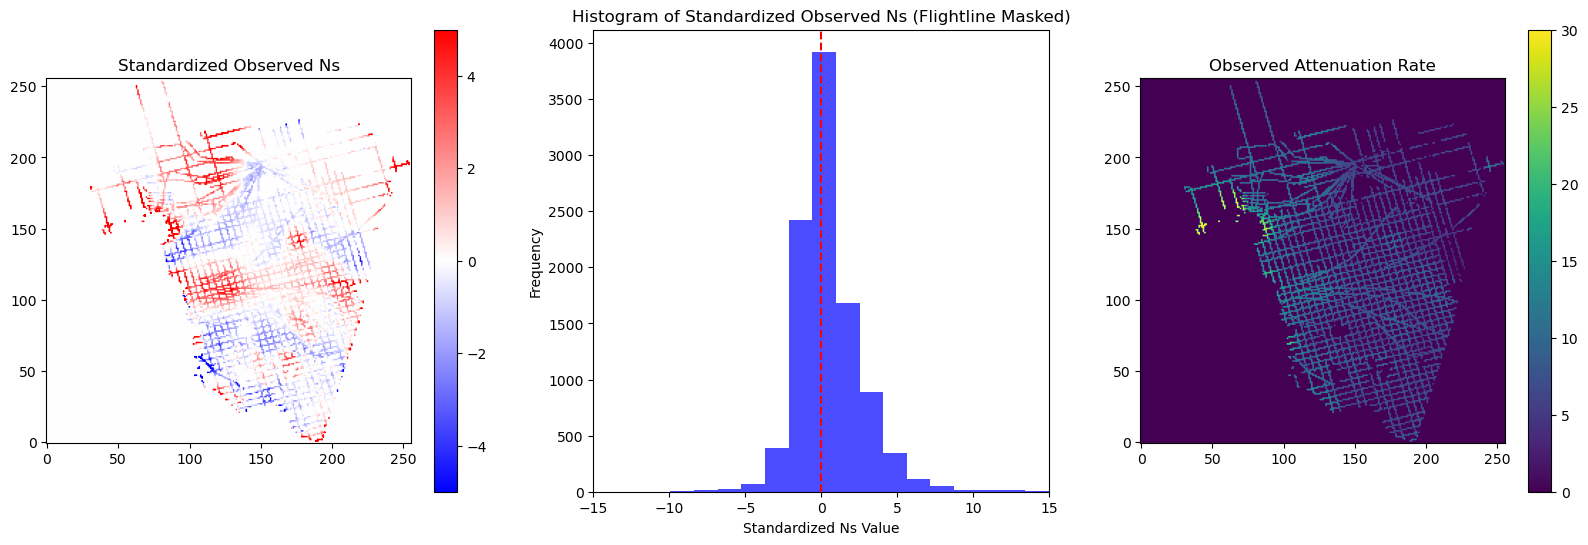

In [4]:
md.load_obs_data(atten_rate_avg)

Density at init: [0.00032939]
 Likelihood: 9.695, Prior: 8.018
 Likelihood: 9.737, Prior: 8.867
 Likelihood: 9.348, Prior: 8.106
 Likelihood: 9.332, Prior: 8.111
 Likelihood: 9.318, Prior: 8.116
 Likelihood: 9.291, Prior: 8.136
 Likelihood: 9.292, Prior: 8.135
 Likelihood: 9.292, Prior: 8.135
 Likelihood: 9.292, Prior: 8.135
 Likelihood: 9.292, Prior: 8.135
 Likelihood: 9.292, Prior: 8.135
Optimization success: True
CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
Iterations: 9
Function evaluations: 11
Final objective: 17.4264
Density at init: [0.00032939]
 Likelihood: 4.500, Prior: 8.018
 Likelihood: 4.318, Prior: 8.201
 Likelihood: 4.368, Prior: 8.064
 Likelihood: 4.361, Prior: 8.069
 Likelihood: 4.363, Prior: 8.065
 Likelihood: 4.361, Prior: 8.065
 Likelihood: 4.358, Prior: 8.068
 Likelihood: 4.357, Prior: 8.069
 Likelihood: 4.357, Prior: 8.069
 Likelihood: 4.357, Prior: 8.069
 Likelihood: 4.357, Prior: 8.069
Optimization success: True
CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTO

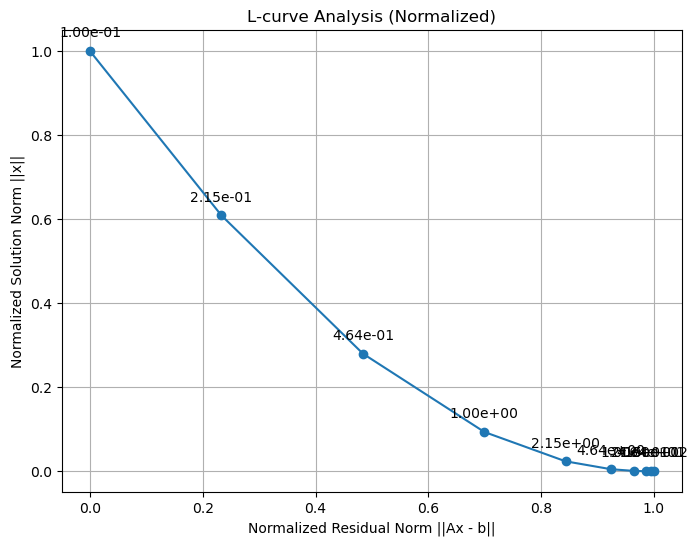

Density at init: [0.00032939]
 Likelihood: 0.970, Prior: 8.018
 Likelihood: 0.955, Prior: 8.027
 Likelihood: 0.957, Prior: 8.025
 Likelihood: 0.956, Prior: 8.026
 Likelihood: 0.957, Prior: 8.024
 Likelihood: 0.957, Prior: 8.024
 Likelihood: 0.957, Prior: 8.024
 Likelihood: 0.957, Prior: 8.024
 Likelihood: 0.957, Prior: 8.024
Optimization success: True
CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
Iterations: 7
Function evaluations: 9
Final objective: 8.9810


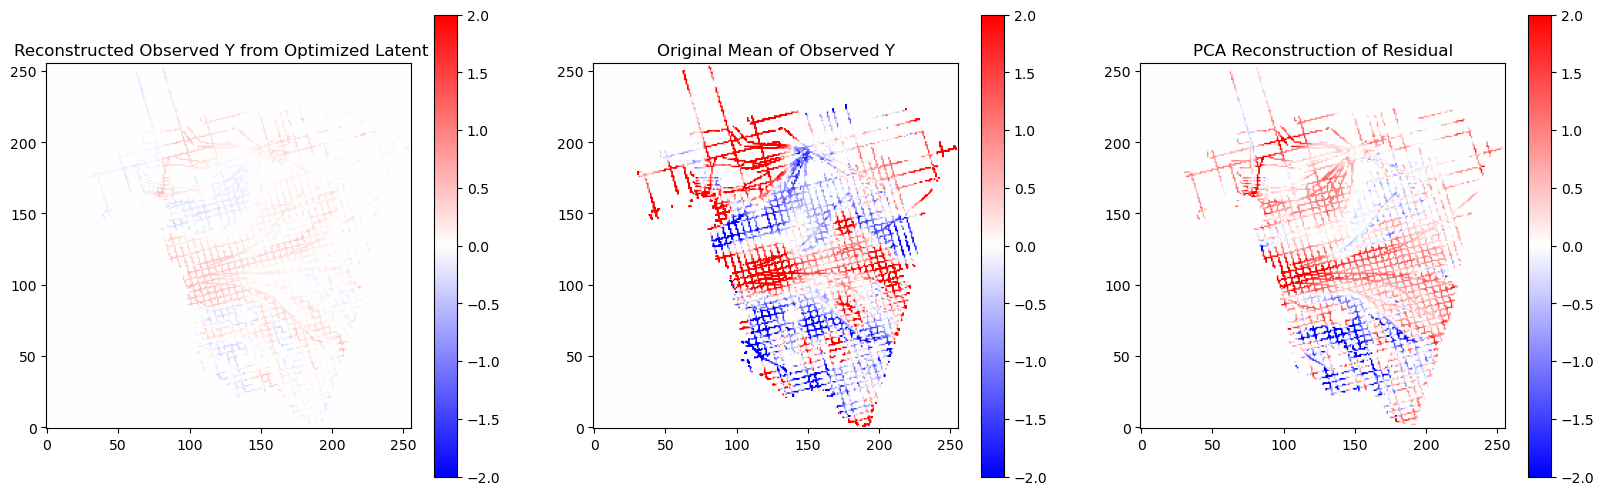

first 5x5 block of cov_obs_latent:
[[8611.04729152  719.22521331 -989.02878034  737.56862474]
 [ 719.22521331  930.88394636 -441.30952898  329.10676499]
 [-989.02878034 -441.30952898  888.72039882 -452.56486613]
 [ 737.56862474  329.10676499 -452.56486613  421.72994186]]
min eigenvalue: 19.794228030930725
conditioned indices are:  [0 1 2 3 4 5 6 7]


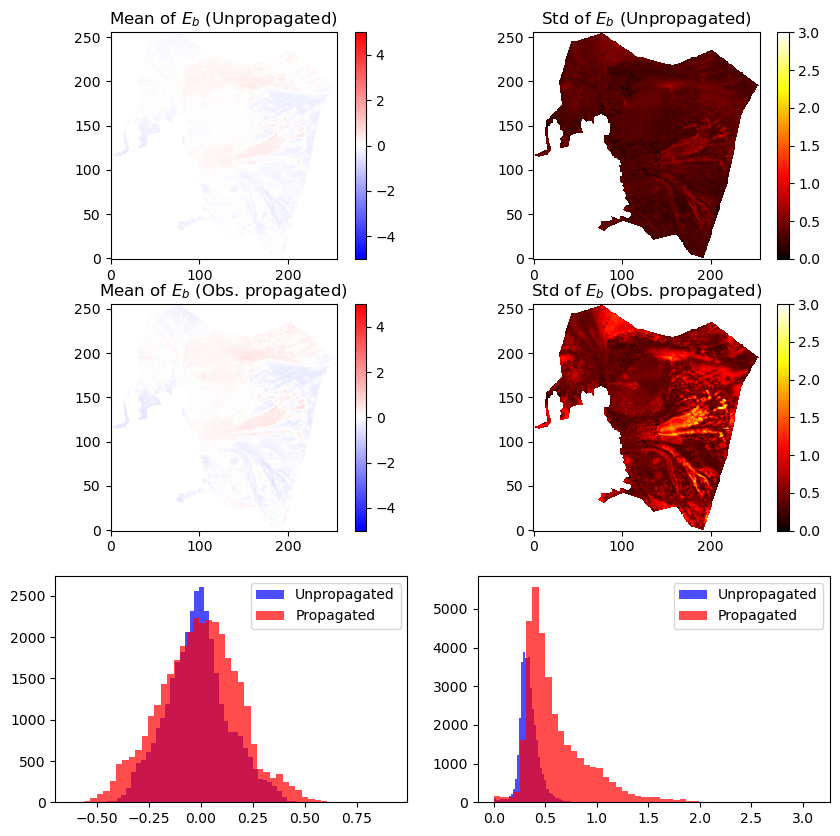

In [5]:
from src.validation import lcurve_analysis
def opt_func(beta):
    return md.compute_optimal_Y_in_latent(beta=beta, show_plot=False)

beta_prior_list = np.logspace(-1, 2, 10)
lcurve_analysis(opt_func=opt_func, beta_prior_list=beta_prior_list)

# the beta_prior comes from the L-curve plot
beta_prior = 1
lambda1, lambda2 = 1,1
md.derive_prior(beta=beta_prior, lambda1=lambda1, lambda2=lambda2)

#### Prior predictive check...

## Part (iv): loading basal thermal evidence

In [6]:
from src.ice import compute_pmp

# load the thawed base and frozen base data
frozen_base_filename = folder + "../../basal-frozen-mask/frozen_mask.mat"
thawed_base_filename = folder + "../../basal-water-mask/water_mask.mat"
frozen_mask = scipy.io.loadmat(frozen_base_filename)['frozen_mask']
thawed_mask = scipy.io.loadmat(thawed_base_filename)['water_mask']
frozen_mask_data = frozen_mask['data'][0][0]
thawed_mask_data = thawed_mask['data'][0][0]

Eb_mean_data = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std_data = scipy.io.loadmat(folder + Eb_std_filename)
# replace nan by 0
Eb_mean_data = np.nan_to_num(Eb_mean_data['Eb_mean'], nan=0.0)
Eb_std_data = np.nan_to_num(Eb_std_data['Eb_std'], nan=0.0)

# compute pmp
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
pmp = compute_pmp(H)

# into a vector
Eb_mean_data = Eb_mean_data.flatten()
Eb_std_data = Eb_std_data.flatten()
frozen_mask_data = frozen_mask_data.flatten()
thawed_mask_data = thawed_mask_data.flatten()

# set fractional area to 1 for all locations (assumption for now, can be relaxed later)
thawed_fractional_area = np.zeros_like(thawed_mask_data)
frozen_fractional_area = np.zeros_like(frozen_mask_data)
thawed_fractional_area[thawed_mask_data == 1] = 1.0
frozen_fractional_area[frozen_mask_data == 1] = 1.0

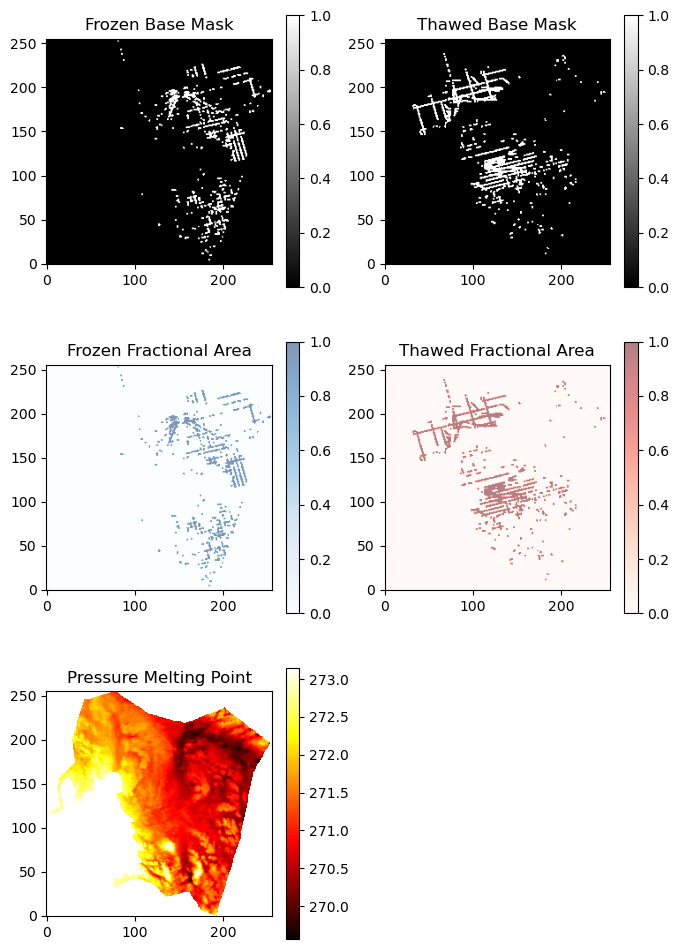

In [38]:
md.load_evidence(thawed_mask_data, thawed_fractional_area,
                 frozen_mask_data, frozen_fractional_area,
                 pmp,
                 show_plot=True)

## Part (v): Computing MAP and posterior distribution

Using beta_posterior =  0.5
Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 75.9668
Starting iteration 2/20...


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/optimization.py:254: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Eb_star_tensor = torch.tensor(Eb_star, requires_grad=True)


Iteration 2/20, Negative Log Posterior: 75.9657
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 75.9652
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 75.9652
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 75.9652
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 75.9652
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 75.9652
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 75.9652
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 75.9652
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 75.9652
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 75.9652
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 75.9652
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 75.9652
Starting iteration 14/20...
Iteration 14/20, Negative Log Posterior: 75.9652
Starting iteration 15/20...
Iteration 15/2

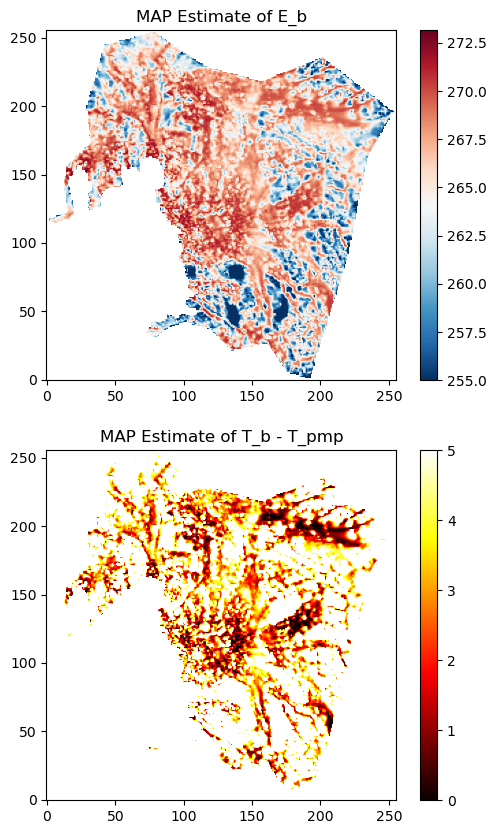

Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 75.9692
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 75.9654
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 75.9652
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 75.9652
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 75.9652
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 75.9652
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 75.9652
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 75.9652
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 75.9652
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 75.9652
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 75.9652
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 75.9652
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 75.9652
Starting iteratio

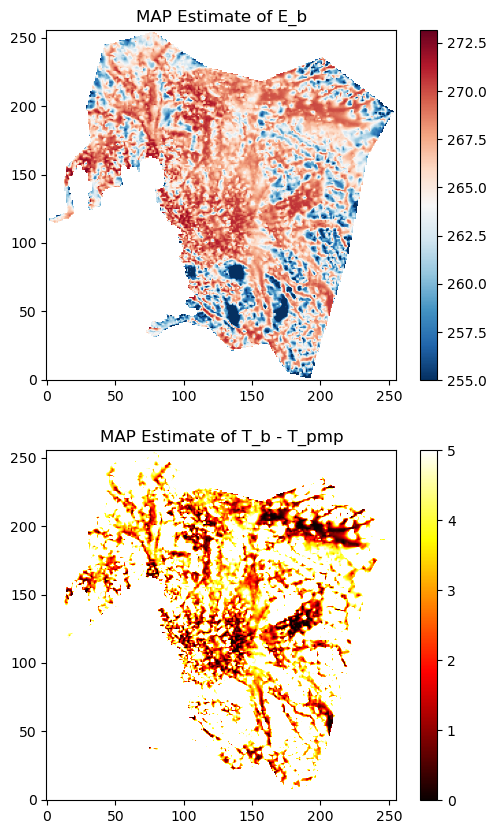

Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 75.9715
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 75.9677
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 75.9652
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 75.9652
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 75.9652
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 75.9652
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 75.9652
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 75.9652
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 75.9652
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 75.9652
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 75.9652
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 75.9652
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 75.9652
Starting iteratio

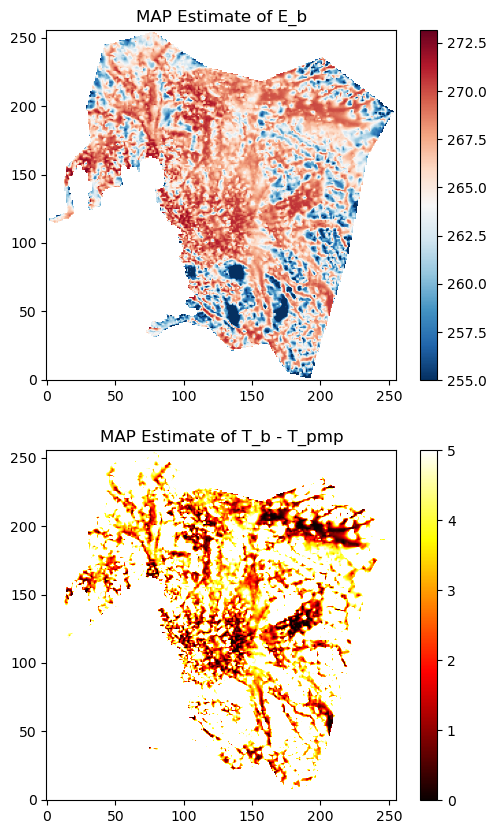

Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 75.9705
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 75.9667
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 75.9652
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 75.9652
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 75.9652
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 75.9652
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 75.9652
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 75.9652
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 75.9652
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 75.9652
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 75.9652
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 75.9652
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 75.9652
Starting iteratio

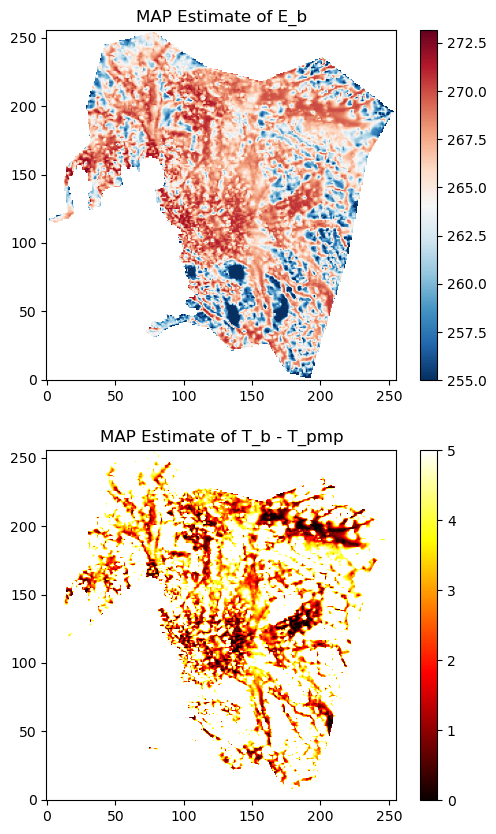

Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 75.9772
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 75.9654
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 75.9652
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 75.9652
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 75.9652
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 75.9652
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 75.9652
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 75.9652
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 75.9652
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 75.9652
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 75.9652
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 75.9652
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 75.9652
Starting iteratio

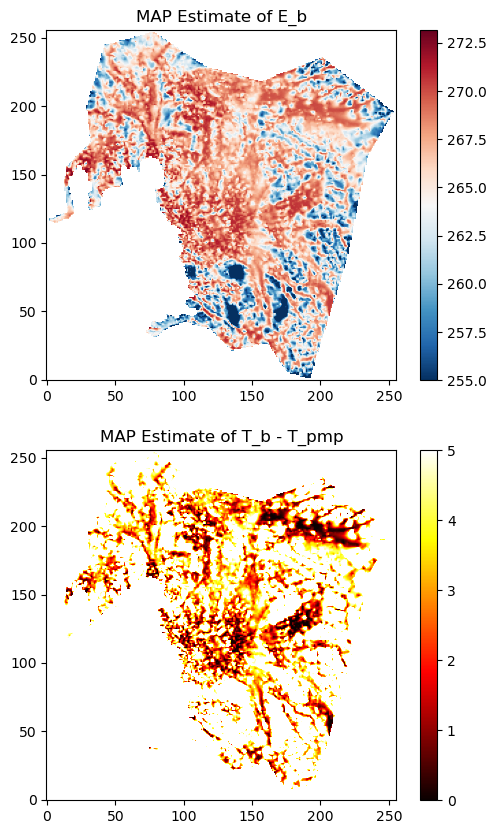

Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 75.9690
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 75.9662
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 75.9652
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 75.9652
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 75.9652
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 75.9652
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 75.9652
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 75.9652
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 75.9652
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 75.9652
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 75.9652
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 75.9652
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 75.9652
Starting iteratio

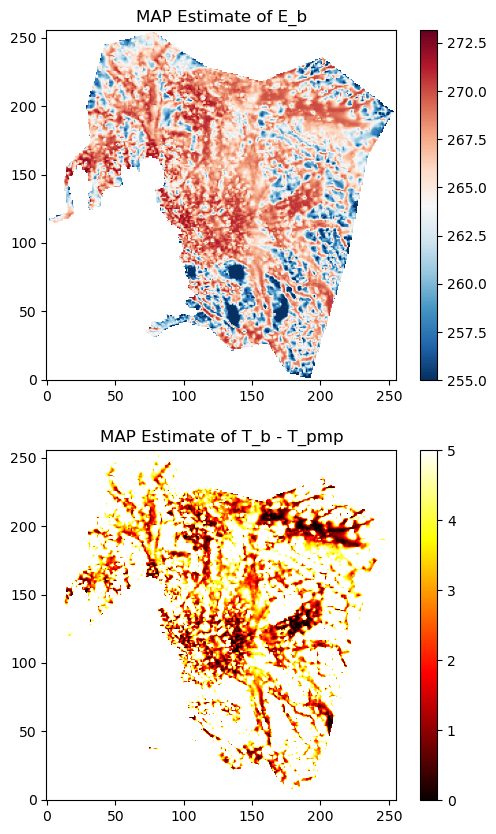

Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 75.9661
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 75.9653
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 75.9652
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 75.9652
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 75.9652
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 75.9652
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 75.9652
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 75.9652
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 75.9652
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 75.9652
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 75.9652
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 75.9652
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 75.9652
Starting iteratio

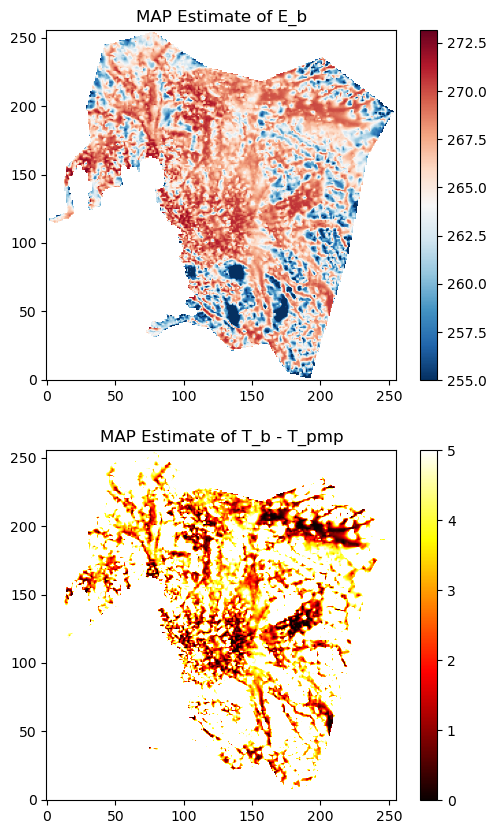

Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 75.9712
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 75.9676
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 75.9652
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 75.9652
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 75.9652
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 75.9652
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 75.9652
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 75.9652
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 75.9652
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 75.9652
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 75.9652
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 75.9652
Starting iteration 13/20...


KeyboardInterrupt: 

In [ ]:
from src.validation import split_evidence
import copy
beta_posterior_list = [0.5, 1, 2, 3, 4, 5]
mask_idx = np.where(md.combined_mask)[0]
subsets_mask_idx = split_evidence(mask_idx, 20)

orig_thawed_mask      = md.thawed_mask.copy()
orig_frozen_mask      = md.frozen_mask.copy()
orig_thawed_frac_area = md.thawed_fractional_area.copy()
orig_frozen_frac_area = md.frozen_fractional_area.copy()
orig_pmp              = md.pmp  # or .copy() if it's an array

Tb_MAP_betas = []

for beta_posterior in beta_posterior_list:
    print("Using beta_posterior = ", beta_posterior)
    md_copy = copy.copy(md)
    
    Tb_MAP_subsets = []
    for ii, mask in enumerate(subsets_mask_idx):
        print(f"  Subset {i}: {len(mask)} pixels, first 5 idx = {mask[:5]}")
        # ── Build the subset evidence ────────────────────────────────
        new_evidence  = np.zeros_like(md_copy.combined_mask, dtype=bool)
        new_frac_area = np.zeros_like(md_copy.combined_mask, dtype=float)
        new_evidence[mask] = True
        new_frac_area[mask] = 1.0

        new_thawed_mask = np.logical_and(orig_thawed_mask, new_evidence)
        new_frozen_mask = np.logical_and(orig_frozen_mask, new_evidence)

        new_thawed_frac_area = np.zeros_like(orig_thawed_frac_area)
        new_frozen_frac_area = np.zeros_like(orig_frozen_frac_area)
        new_thawed_frac_area[new_thawed_mask] = 1.0
        new_frozen_frac_area[new_frozen_mask] = 1.0

        # ── Load subset evidence and compute MAP ─────────────────────
        md_copy.load_evidence(new_thawed_mask, new_thawed_frac_area,
                         new_frozen_mask, new_frozen_frac_area,
                         orig_pmp,
                         show_plot=False)

        md_copy.compute_MAP(beta=beta_posterior, n_iter=20, lr=0.5)
        Tb_MAP_subsets.append(md_copy.Tb_MAP.copy())

    Tb_MAP_subsets_array = np.array(Tb_MAP_subsets)
    Tb_MAP_betas.append(Tb_MAP_subsets_array)


Starting iteration 1/20...


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/optimization.py:254: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Eb_star_tensor = torch.tensor(Eb_star, requires_grad=True)


Iteration 1/20, Negative Log Posterior: 3770.0213
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 3709.4053
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 3695.4573
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 3695.4370
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 3695.4368
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 3695.4368
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 3695.4368
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 3695.4368
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 3695.4368
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 3695.4368
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 3695.4368
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 3695.4368
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 3695.4368
Starting iteration

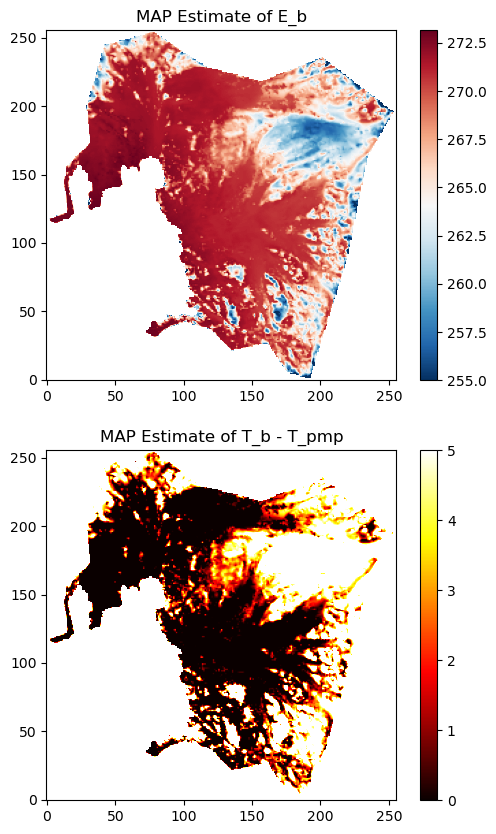

In [43]:
beta_posterior = 1
md.compute_MAP(beta=beta_posterior, n_iter=20, lr=0.5)

In [42]:
md.X_std.shape

(65536,)

Total consistent points: 5428 out of 6403 (84.77%)


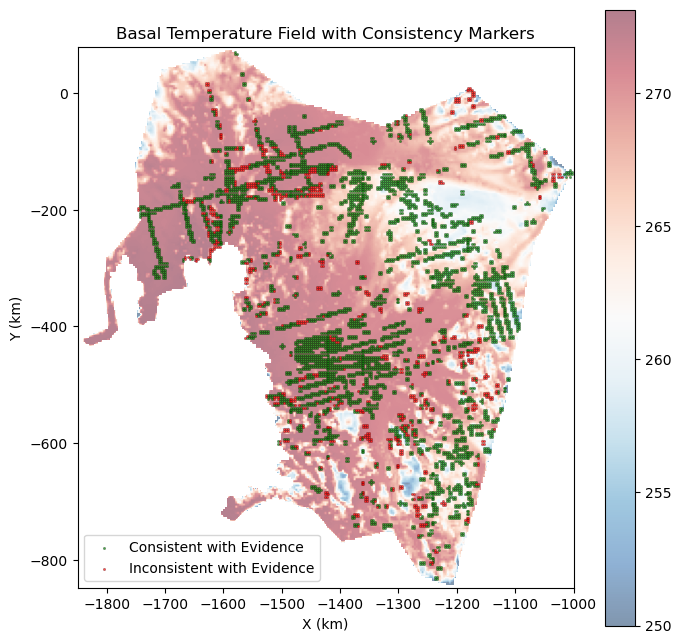

In [12]:
md.plot_evidence_consistency(md.Tb_MAP.flatten(), beta=beta_posterior)

In [ ]:
md.derive_posterior(beta=beta_posterior, warmup_steps=2000)

Starting HMC sampling: 4000 samples, 1000 warmup...


Sample: 100%|██████████| 5000/5000 [1:24:25,  1.01s/it, step size=3.80e-02, acc. prob=0.822]


In [45]:
md.analyze_posterior_samples(beta=beta_posterior, loading=True)

/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/model.py:903: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.mcmc_md = torch.load(f"../d

HMC Sampling Complete. Extracted shape: (4000, 25)


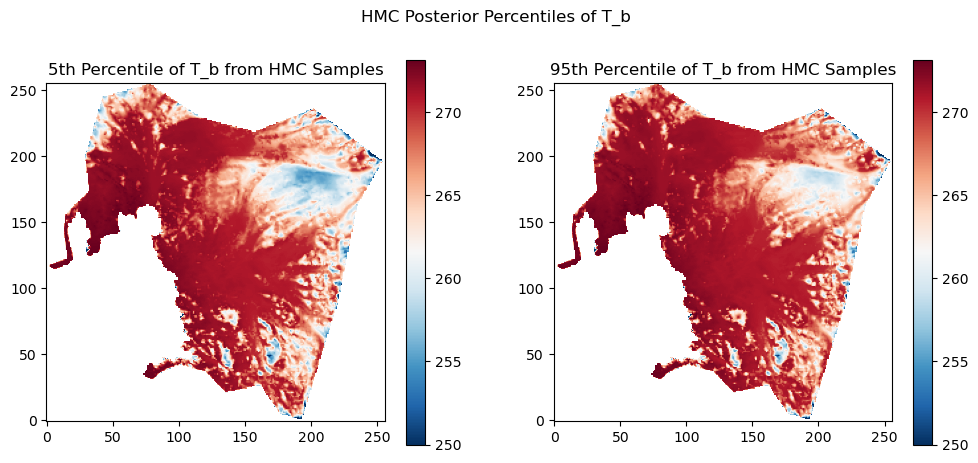

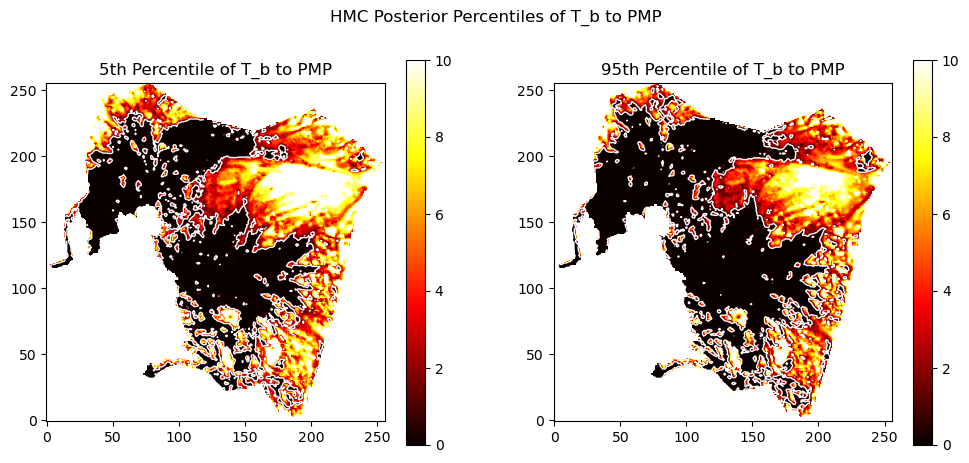

In [46]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(md.Tb_p5, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('5th Percentile of T_b from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(md.Tb_p95, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('95th Percentile of T_b from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('HMC Posterior Percentiles of T_b')
plt.show()

deg2pmp_p5 = (md.pmp - md.Tb_p5.flatten()).reshape(md.nx, md.ny)
deg2pmp_p95 = (md.pmp - md.Tb_p95.flatten()).reshape(md.nx, md.ny)
deg2pmp_p5[md.domain_mask == False] = np.nan
deg2pmp_p95[md.domain_mask == False] = np.nan
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(deg2pmp_p5, cmap='hot', vmin=0, vmax=10)
plt.colorbar()  
# add contourline of 1
plt.contour(deg2pmp_p5, levels=[1], colors='white', linewidths=1)
plt.title('5th Percentile of T_b to PMP')
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(deg2pmp_p95 , cmap='hot', vmin=0, vmax=10)
plt.colorbar()
# add contourline of 1
plt.contour(deg2pmp_p95, levels=[1], colors='white', linewidths=1)
plt.title('95th Percentile of T_b to PMP')
plt.gca().invert_yaxis()
plt.suptitle('HMC Posterior Percentiles of T_b to PMP')
plt.show()

--- HMC Sampling Metrics ---
Total Samples Drawn: 4000
Mean ESS across all dimensions: 322.51
Minimum ESS (Worst mixing dimension): 27.61
Maximum ESS (Best mixing dimension): 835.38
Post-Burn-in Mean ESS: 246.76
Post-Burn-in Min ESS: 19.38


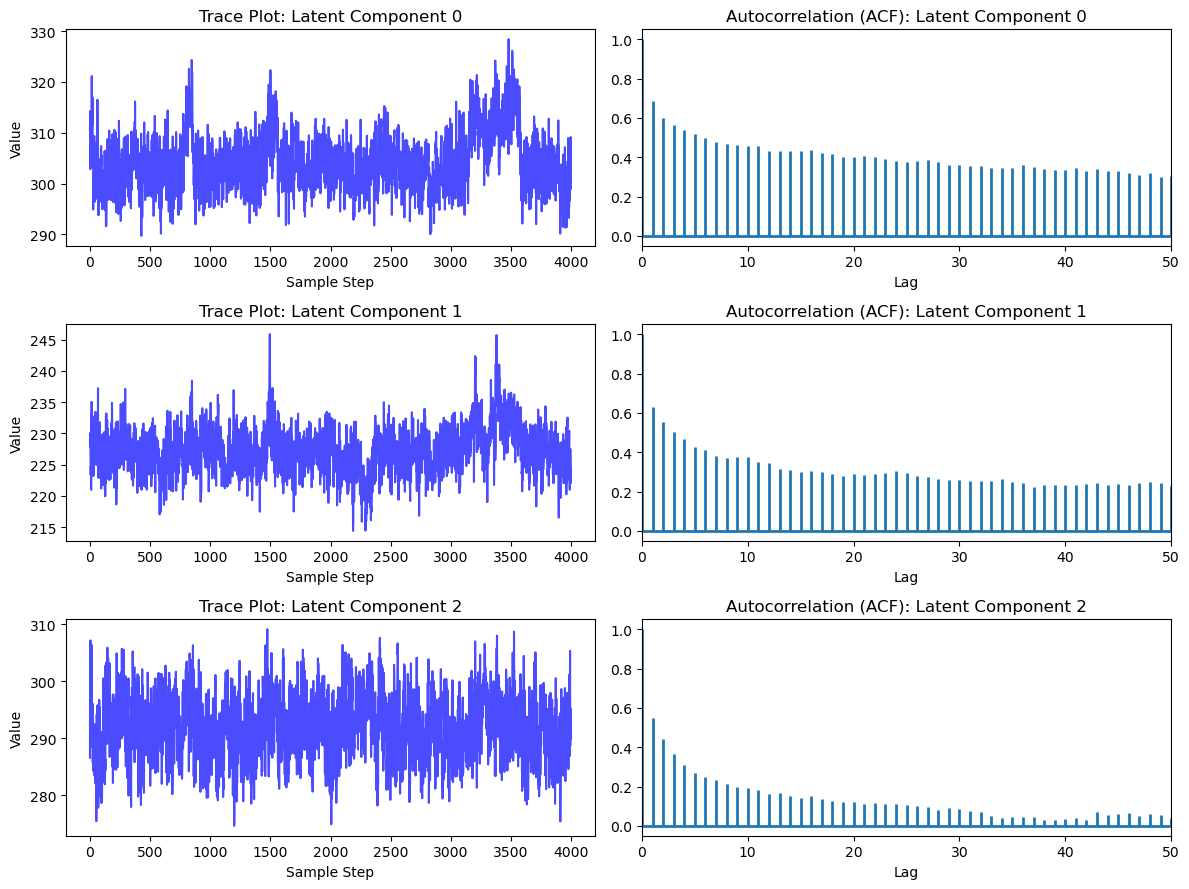

In [18]:
md.posterior_quality_check(slicing=1000)